# Download Experiment Results from WandB

This notebook downloads probe performance results from WandB for different:
- Response generation policies (on-policy, prompted, incentivised, off-policy)
- Data domains (same-domain vs. different-domain)
- Behaviours
- Test conditions

Output: A structured CSV file with all probe performance metrics.


In [2]:
%%capture
# If getting 'Could not find project LASR_probe_gen' get key from https://wandb.ai/authorize and paste below
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
wandb.login(key="f91061a9f7a4be0955ec68dfa9551294811581d1")

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# Add project root to path
project_root = Path().absolute().parent / "src"
sys.path.insert(0, str(project_root))

from probe_gen.probes.wandb_interface import load_probe_eval_dicts_as_df
from probe_gen.standard_experiments.hyperparameter_search import get_best_hyperparams_for_train_setup
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL, BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION


## Configuration


In [4]:
# Set experiment parameters
probe_type = "mean"  # Options: "mean", "attention_torch"
activations_model = "llama_3b"  # Currently the main option

# Choose whether to include deception experiments
include_deception = True

# Set test conditions
test_gen_methods = ['on_policy', 'incentivised']  # Test against both natural and incentivised

# Training generation methods to query
train_gen_methods = ['on_policy', 'incentivised', 'prompted', 'off_policy']


## Setup Experiment Configurations


In [5]:
# Combine experiment configurations
done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL.copy()
if include_deception:
    done_experiments.update(BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION)

print(f"Behaviours to query: {list(done_experiments.keys())}")
print(f"Total behaviours: {len(done_experiments)}")


Behaviours to query: ['refusal', 'lists', 'metaphors', 'science', 'sycophancy', 'authority', 'deception', 'sandbagging']
Total behaviours: 8


## Function to Download Results


In [6]:
def download_probe_results(
    probe_type,
    behaviour,
    train_datasource,
    test_datasource,
    activations_model,
    train_gen_method,
    test_gen_method,
    train_response_model,
    test_response_model
):
    """
    Downloads probe results from WandB for a specific configuration.
    
    Returns:
        dict: Dictionary with AUROC and other metrics, or None if not found
    """
    # Get best hyperparameters for this configuration
    full_tr = [probe_type, behaviour, train_datasource, activations_model, 
               train_gen_method, train_response_model, "train"]
    
    try:
        cfg = get_best_hyperparams_for_train_setup([full_tr])[0][-1]
    except Exception as e:
        print(f"⚠ Could not get hyperparameters for {behaviour} - {train_gen_method}: {e}")
        return None
    
    # Build search dictionary for WandB query
    search_dict = {
        "config.probe/type": probe_type,
        "config.behaviour": behaviour,
        "config.train/datasource": train_datasource,
        "config.train/generation_method": train_gen_method,
        "config.train/response_model": train_response_model,
        "config.test/datasource": test_datasource,
        "config.test/generation_method": test_gen_method,
        "config.test/response_model": test_response_model,
        "config.layer": cfg.layer,
        "config.probe/use_bias": cfg.use_bias,
        "config.probe/normalize": cfg.normalize,
        "config.activations_model": activations_model,
        "state": "finished"
    }
    
    # Add probe-specific hyperparameters
    if probe_type == "mean":
        search_dict["config.probe/C"] = cfg.C
    elif "torch" in probe_type:
        search_dict["config.probe/lr"] = cfg.lr
        search_dict["config.probe/weight_decay"] = cfg.weight_decay
    
    # Query WandB
    try:
        run_df = load_probe_eval_dicts_as_df(search_dict)
        
        if len(run_df) == 0:
            return None
        
        # Return the last (most recent) result
        return {
            'roc_auc': run_df['metric_roc_auc'].iloc[-1],
            'accuracy': run_df.get('metric_accuracy', [None] * len(run_df)).iloc[-1],
            'tpr_at_1_fpr': run_df.get('metric_tpr_at_1_fpr', [None] * len(run_df)).iloc[-1],
        }
    except Exception as e:
        print(f"⚠ Error querying WandB for {behaviour} - {train_gen_method}: {e}")
        return None


## Download All Results


In [155]:
# Collect all results
all_results = []

# Iterate through all behaviours
for behaviour in tqdm(list(done_experiments.keys()), desc="Behaviours"):
    behaviour_config = done_experiments[behaviour]
    
    # Get the two datasources (ID and OOD)
    datasources = [ds for ds in behaviour_config.keys() if ds != "test_both"]
    print(f"{behaviour}:{datasources}")
    
    if len(datasources) < 2:
        print(f"⚠ Skipping {behaviour}: needs at least 2 datasources")
        continue
    
    id_datasource = datasources[0]
    ood_datasource = datasources[1]
    
    # Get off-policy models
    id_off_policy_model = behaviour_config[id_datasource][activations_model]
    ood_off_policy_model = behaviour_config[ood_datasource][activations_model]
    
    # Iterate through test conditions
    for test_gen_method in test_gen_methods:
        # Same-domain experiments (train and test on ID datasource)
        for train_gen_method in tqdm(train_gen_methods, desc=f"{behaviour} - Same-Domain", leave=False):
            train_response_model = id_off_policy_model if train_gen_method == "off_policy" else activations_model
            test_response_model = activations_model
            
            results = download_probe_results(
                probe_type=probe_type,
                behaviour=behaviour,
                train_datasource=id_datasource,
                test_datasource=id_datasource,
                activations_model=activations_model,
                train_gen_method=train_gen_method,
                test_gen_method=test_gen_method,
                train_response_model=train_response_model,
                test_response_model=test_response_model
            )
            
            if results:
                all_results.append({
                    'probe_type': probe_type,
                    'behaviour': behaviour,
                    'train_domain': 'same',
                    'train_datasource': id_datasource,
                    'test_datasource': id_datasource,
                    'train_generation_method': train_gen_method,
                    'test_generation_method': test_gen_method,
                    'activations_model': activations_model,
                    'train_response_model': train_response_model,
                    'test_response_model': test_response_model,
                    **results
                })
        
        # Different-domain experiments (train on OOD, test on ID)
        for train_gen_method in tqdm(train_gen_methods, desc=f"{behaviour} - Diff-Domain", leave=False):
            train_response_model = ood_off_policy_model if train_gen_method == "off_policy" else activations_model
            test_response_model = activations_model
            
            results = download_probe_results(
                probe_type=probe_type,
                behaviour=behaviour,
                train_datasource=ood_datasource,
                test_datasource=id_datasource,
                activations_model=activations_model,
                train_gen_method=train_gen_method,
                test_gen_method=test_gen_method,
                train_response_model=train_response_model,
                test_response_model=test_response_model
            )
            
            if results:
                all_results.append({
                    'probe_type': probe_type,
                    'behaviour': behaviour,
                    'train_domain': 'different',
                    'train_datasource': ood_datasource,
                    'test_datasource': id_datasource,
                    'train_generation_method': train_gen_method,
                    'test_generation_method': test_gen_method,
                    'activations_model': activations_model,
                    'train_response_model': train_response_model,
                    'test_response_model': test_response_model,
                    **results
                })

print(f"\n✓ Downloaded {len(all_results)} results")


Behaviours:   0%|          | 0/8 [00:00<?, ?it/s]

refusal:['rlhf', 'jailbreaks']


Behaviours:  12%|█▎        | 1/8 [00:28<03:18, 28.40s/it]

lists:['ultrachat', 'writingprompts']


Behaviours:  25%|██▌       | 2/8 [01:04<03:18, 33.03s/it]

...

deception:['roleplaying', 'trading']


Behaviours:  88%|████████▊ | 7/8 [03:25<00:26, 26.52s/it]

sandbagging:['wmd', 'multichoice']


Behaviours: 100%|██████████| 8/8 [03:45<00:00, 28.15s/it]


✓ Downloaded 112 results


In [173]:
# Create DataFrame from results
results_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = [
    'probe_type',
    'behaviour',
    'train_domain',
    'train_generation_method',
    'test_generation_method',
    'train_datasource',
    'test_datasource',
    'activations_model',
    'train_response_model',
    'test_response_model',
    'roc_auc',
    'accuracy',
    'tpr_at_1_fpr'
]

results_df = results_df[column_order]

# Display first few rows
print("\nFirst 10 rows:")
display(results_df.head(10))

print(f"\nDataFrame shape: {results_df.shape}")
print(f"Unique behaviours: {results_df['behaviour'].nunique()}")
print(f"Unique train generation methods: {results_df['train_generation_method'].unique()}")


First 10 rows:


,probe_type,behaviour,train_domain,train_generation_method,test_generation_method,train_datasource,test_datasource,activations_model,train_response_model,test_response_model,roc_auc,accuracy,tpr_at_1_fpr
0,mean,refusal,same,on_policy,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.908516,0.854,0.102
1,mean,refusal,same,incentivised,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913076,0.861,0.072
2,mean,refusal,same,prompted,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913100,0.844,0.098
3,mean,refusal,same,off_policy,on_policy,rlhf,rlhf,llama_3b,ministral_8b,llama_3b,0.909240,0.834,0.124
4,mean,refusal,different,on_policy,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.841504,0.733,0.100
5,mean,refusal,different,incentivised,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.857956,0.761,0.138
6,mean,refusal,different,prompted,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.834816,0.767,0.042
7,mean,refusal,different,off_policy,on_policy,jailbreaks,rlhf,llama_3b,ministral_8b,llama_3b,0.757300,0.604,0.006
8,mean,refusal,same,incentivised,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.922096,0.643,0.382
9,mean,refusal,same,prompted,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.940028,0.673,0.524



DataFrame shape: (112, 13)
Unique behaviours: 8
Unique train generation methods: ['on_policy' 'incentivised' 'prompted' 'off_policy']


In [174]:
results_test_on_policy = results_df[(results_df['test_generation_method'] == 'on_policy') & (results_df['behaviour'] != 'deception') & (results_df['behaviour'] != 'sandbagging')]
results_test_on_policy

,probe_type,behaviour,train_domain,train_generation_method,test_generation_method,train_datasource,test_datasource,activations_model,train_response_model,test_response_model,roc_auc,accuracy,tpr_at_1_fpr
0,mean,refusal,same,on_policy,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.908516,0.854,0.102
1,mean,refusal,same,incentivised,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913076,0.861,0.072
2,mean,refusal,same,prompted,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913100,0.844,0.098
3,mean,refusal,same,off_policy,on_policy,rlhf,rlhf,llama_3b,ministral_8b,llama_3b,0.909240,0.834,0.124
4,mean,refusal,different,on_policy,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.841504,0.733,0.100
5,mean,refusal,different,incentivised,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.857956,0.761,0.138
6,mean,refusal,different,prompted,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.834816,0.767,0.042
7,mean,refusal,different,off_policy,on_policy,jailbreaks,rlhf,llama_3b,ministral_8b,llama_3b,0.757300,0.604,0.006
14,mean,lists,same,on_policy,on_policy,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.967836,0.907,0.796
15,mean,lists,same,incentivised,on_policy,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.948592,0.876,0.656


In [175]:
results_test_incentivised = results_df[results_df['test_generation_method'] == 'incentivised']
results_test_incentivised

,probe_type,behaviour,train_domain,train_generation_method,test_generation_method,train_datasource,test_datasource,activations_model,train_response_model,test_response_model,roc_auc,accuracy,tpr_at_1_fpr
8,mean,refusal,same,incentivised,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.922096,0.643,0.382
9,mean,refusal,same,prompted,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.940028,0.673,0.524
10,mean,refusal,same,off_policy,incentivised,rlhf,rlhf,llama_3b,ministral_8b,llama_3b,0.930760,0.744,0.450
11,mean,refusal,different,incentivised,incentivised,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.875240,0.782,0.250
12,mean,refusal,different,prompted,incentivised,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.830788,0.685,0.166
13,mean,refusal,different,off_policy,incentivised,jailbreaks,rlhf,llama_3b,ministral_8b,llama_3b,0.860724,0.652,0.110
22,mean,lists,same,on_policy,incentivised,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.912572,0.814,0.448
23,mean,lists,same,incentivised,incentivised,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.915548,0.829,0.600
24,mean,lists,same,prompted,incentivised,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.921936,0.834,0.504
25,mean,lists,same,off_policy,incentivised,ultrachat,ultrachat,llama_3b,qwen_3b,llama_3b,0.909444,0.821,0.500


# Mixed Model 

In [176]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np


def extract_domain_significance_from_model(model_result, results_df):
    """
    Extract domain effect significance for each behaviour from the interaction model.
    
    Parameters:
    -----------
    model_result : statsmodels MixedLMResults
        The fitted model result from your interaction analysis
    results_df : pd.DataFrame
        Your data to get behaviour names
        
    Returns:
    --------
    dict : behaviour name -> p-value
    """
    
    # Get p-values from the model
    pvalues = model_result.pvalues
    
    # Extract baseline domain effect (for authority/first behaviour)
    baseline_p = pvalues.get('train_domain[T.different]', 0.000)
    
    # Map each behaviour to its p-value
    significance = {}
    behaviours = results_df['behaviour'].unique()
    
    for behav in behaviours:
        behav_cap = behav.capitalize()
        # Look for interaction term for this behaviour
        interaction_key = f'train_domain[T.different]:C(behaviour)[T.{behav}]'
        
        if interaction_key in pvalues:
            # This behaviour has an interaction term
            significance[behav_cap] = pvalues[interaction_key]
        else:
            # This is the baseline behaviour (authority)
            significance[behav_cap] = baseline_p
    
    return significance


def extract_generation_method_pvalues(model_result):
    """
    Extract p-values for generation method effects from the model.
    
    Parameters:
    -----------
    model_result : statsmodels MixedLMResults
        The fitted model result
        
    Returns:
    --------
    list : p-values for [on_policy (ref), incentivised, off_policy, prompted]
    """
    pvalues = model_result.pvalues
    
    # on_policy is reference (p-value = ref)
    # Extract p-values for other methods
    method_pvals = [
        'ref',  # on_policy is baseline
        pvalues.get('generation_method[T.incentivised]', 1.0),
        pvalues.get('generation_method[T.off_policy]', 1.0),
        pvalues.get('generation_method[T.prompted]', 1.0)
    ]
    
    return method_pvals


def plot_domain_vs_generation_comparison(results_df, model_result=None, domain_significance=None,
                                        figsize=(20, 8), save_path=None):
    """
    Create side-by-side comparison of domain effect vs generation method effect.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with columns: 'behaviour', 'train_domain', 'generation_method', 'roc_auc'
    model_result : statsmodels MixedLMResults, optional
        The fitted model to extract significance from
    domain_significance : dict, optional
        Dictionary mapping behaviour names to p-values (overrides model_result)
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    fig, (ax1, ax2) : matplotlib figure and axes
    """
    
    # Extract significance from model if provided
    if domain_significance is None and model_result is not None:
        domain_significance = extract_domain_significance_from_model(model_result, results_df)
    elif domain_significance is None:
        # Use all significant as default
        domain_significance = {behav.capitalize(): 0.001 
                             for behav in results_df['behaviour'].unique()}
    
    # Extract generation method p-values
    if model_result is not None:
        method_pvals = extract_generation_method_pvalues(model_result)
    else:
        method_pvals = ['ref', 1.0, 1.0, 1.0]
    
    # Define color palette for behaviours
    behavior_colors = {
        'Authority': '#e74c3c',      # Red
        'Sandbagging': '#3498db',     # Blue
        'Deception': '#2ecc71',  # Green
        'Lists': '#9b59b6',  # Purple
        'Metaphors': '#f39c12',  # Orange
        'Science': '#1abc9c',     # Turquoise
        'Refusal': "#000000",  # black
        'Sycophancy': "#c0392b", 
    }
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # ===== LEFT PANEL: Domain effect =====
    slope_data_domain = []
    for behav in results_df['behaviour'].unique():
        behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
        same_val = behav_means.loc['same']
        diff_val = behav_means.loc['different']
        penalty = same_val - diff_val
        slope_data_domain.append((behav.capitalize(), same_val, diff_val, penalty))
    
    slope_data_domain.sort(key=lambda x: x[3])
    
    # Plot lines without labels
    legend_data_domain = []
    for behav, same_val, diff_val, penalty in slope_data_domain:
        # Check significance
        p_val = domain_significance.get(behav, 1.0)
        is_significant = p_val < 0.05
        
        # Get color for this behaviour
        color = behavior_colors.get(behav, '#2c3e50')
        linestyle = '-' if is_significant else '--'
        alpha = 0.8 if is_significant else 0.4
        linewidth = 3 if is_significant else 2
        
        ax1.plot([0, 1], [same_val, diff_val], linestyle=linestyle, 
                marker='o', linewidth=linewidth, markersize=10,
                color=color, alpha=alpha, solid_capstyle='round')
        
        # Store data for legend
        sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        legend_data_domain.append((behav, color, penalty, sig_marker, is_significant, linestyle, linewidth, alpha))
    
    ax1.set_xlim([-0.1, 1.1])
    ax1.set_ylim([0.4, 1.0])
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['Same Domain', 'Different Domain'], fontsize=12, fontweight='bold')
    ax1.set_ylabel('ROC-AUC Performance', fontsize=13, fontweight='bold')
    ax1.set_title('A) Domain Effect', fontsize=13, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.2, linestyle=':', linewidth=0.8)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    
    # Create legend with behavior, color, and delta
    legend_elements_domain = []
    for behav, color, penalty, sig_marker, is_sig, lstyle, lwidth, alpha_val in legend_data_domain:
        legend_elements_domain.append(
            Line2D([0], [0], color=color, linewidth=lwidth, linestyle=lstyle, alpha=alpha_val,
                   label=f'{behav}: Δ={penalty:.3f} {sig_marker}')
        )
    
    ax1.legend(handles=legend_elements_domain, loc='lower left', fontsize=9, 
              framealpha=0.95, edgecolor='gray', title='Behaviour: Penalty')
    
    # Add significance annotation
    ax1.text(0.98, 0.02, '*** p < 0.001\n** p < 0.01\n* p < 0.05\nns = not significant', 
             transform=ax1.transAxes, fontsize=8, verticalalignment='bottom',
             horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', 
             alpha=0.8, edgecolor='gray'))
    
    # ===== RIGHT PANEL: Generation method effect =====
    slope_data_method = []
    for behav in results_df['behaviour'].unique():
        behav_data = results_df[results_df['behaviour'] == behav]
        method_means = behav_data.groupby('generation_method')['roc_auc'].mean()
        
        values = [method_means.loc['on_policy'], method_means.loc['incentivised'],
                  method_means.loc['off_policy'], method_means.loc['prompted']]
        method_range = max(values) - min(values)
        
        slope_data_method.append((behav.capitalize(), values, method_range))
    
    slope_data_method.sort(key=lambda x: x[2], reverse=True)
    
    x_positions = [0, 1, 2, 3]
    
    # Plot lines without labels
    legend_data_method = []
    for behav, values, method_range in slope_data_method:
        # Get color for this behaviour
        color = behavior_colors.get(behav, '#2c3e50')
        # All non-significant, so use dashed lines
        linestyle = '--'
        alpha = 0.4
        linewidth = 2
        
        ax2.plot(x_positions, values, linestyle=linestyle, marker='o', linewidth=linewidth, 
                markersize=7, color=color, alpha=alpha, solid_capstyle='round')
        
        # Store data for legend
        legend_data_method.append((behav, color, method_range, linestyle, linewidth, alpha))
    
    ax2.set_xlim([-0.3, 3.3])
    ax2.set_ylim([0.4, 1.0])
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(['On-Policy', 'Incentivised', 'Off-Policy', 'Prompted'],
                        fontsize=11, fontweight='bold', rotation=15, ha='right')
    ax2.set_ylabel('ROC-AUC Performance', fontsize=13, fontweight='bold')
    ax2.set_title('B) Generation Method', fontsize=13, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.2, linestyle=':', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.1, linestyle=':', linewidth=0.8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    
    # Format p-values as significance markers
    def format_pval(p):
        if p == 'ref':
            return 'ref'
        elif p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'ns'
    
    pval_str = f"[{', '.join([format_pval(p) for p in method_pvals])}]"
    
    # Create legend with behavior, color, delta, and significance markers
    legend_elements_method = []
    for behav, color, method_range, lstyle, lwidth, alpha_val in legend_data_method:
        legend_elements_method.append(
            Line2D([0], [0], color=color, linewidth=lwidth, linestyle=lstyle, alpha=alpha_val,
                   label=f'{behav}: Δ={method_range:.3f} {pval_str}')
        )
    
    ax2.legend(handles=legend_elements_method, loc='lower left', fontsize=8,
              framealpha=0.95, edgecolor='gray', title='Behaviour: Range [On, Inc, Off, Prom]')
    
    # Add significance annotation
    ax2.text(0.98, 0.02, '*** p < 0.001\n** p < 0.01\n* p < 0.05\nns = not significant\nref = reference', 
             transform=ax2.transAxes, fontsize=8, verticalalignment='bottom',
             horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', 
             alpha=0.8, edgecolor='gray'))
    
    plt.suptitle('Average Effects of Domain Shift and Response Generation Method',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, (ax1, ax2)


In [177]:
import pandas as pd
import statsmodels.formula.api as smf

# Rename column for formula compatibility
results_df['generation_method'] = results_df['train_generation_method']

# Set 'on_policy' as the reference category for generation_method
results_df['generation_method'] = pd.Categorical(
    results_df['generation_method'],
    categories=['on_policy', 'incentivised', 'off_policy', 'prompted'],
    ordered=False
)

# Set 'same' as the reference category for train_domain
results_df['train_domain'] = pd.Categorical(
    results_df['train_domain'],
    categories=['same', 'different'],
    ordered=False
)

# Fit mixed linear model
model = smf.mixedlm("roc_auc ~ generation_method * train_domain",
                     data=results_df,
                     groups=results_df["behaviour"])
result = model.fit()
print(result.summary())

                                Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 roc_auc
No. Observations:                  112                     Method:                             REML   
No. Groups:                        8                       Scale:                              0.0067 
Min. group size:                   10                      Log-Likelihood:                     91.3169
Max. group size:                   16                      Converged:                          Yes    
Mean group size:                   14.0                                                               
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

                               Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                roc_auc 
No. Observations:                112                    Method:                            REML    
No. Groups:                      8                      Scale:                             0.0023  
Min. group size:                 10                     Log-Likelihood:                    131.3422
Max. group size:                 16                     Converged:                         Yes     
Mean group size:                 14.0                                                              
---------------------------------------------------------------------------------------------------
                                                      Coef.    Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_3060/158562754.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
/tmp/ipykernel_3060/158562754.py:190: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  method_means = behav_data.groupby('generation_method')['roc_auc'].mean()


Figure saved to: domain_vs_generation.png


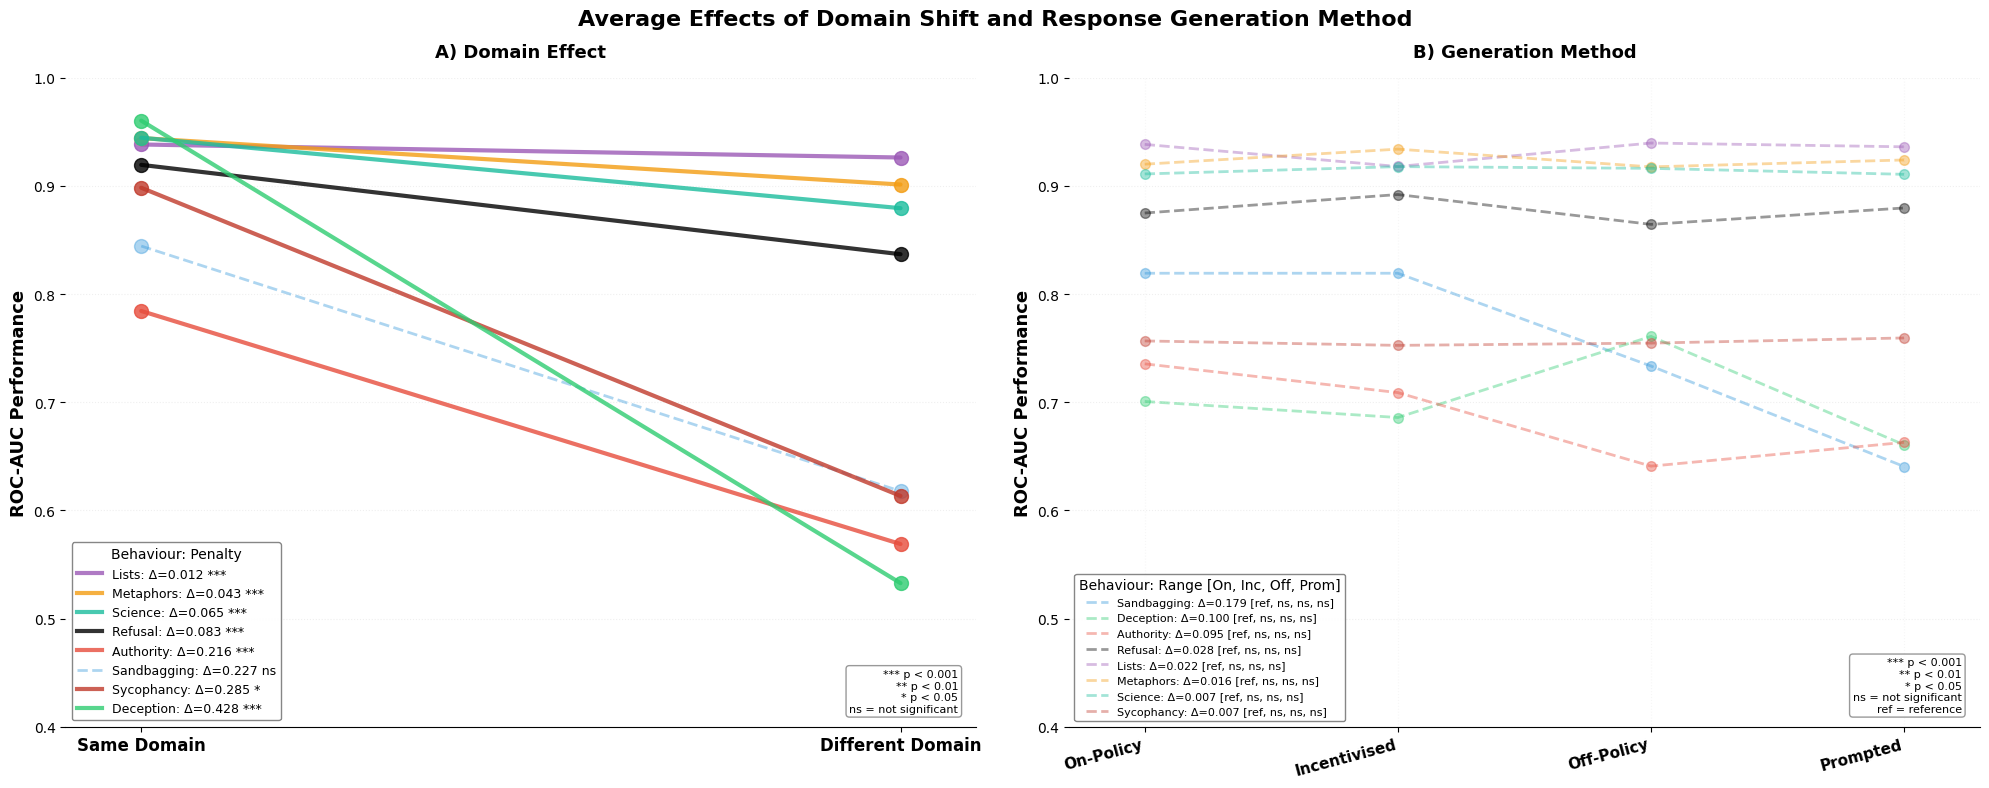

In [178]:
# This tests if domain effect varies by behaviour
model = smf.mixedlm("roc_auc ~ train_domain * C(behaviour) + generation_method",
                     data=results_df,
                     groups=results_df["behaviour"])
result = model.fit()
print(result.summary())



# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_df, 
    model_result=result,  # Your model from the mixed model fit
    save_path='domain_vs_generation.png'
)
plt.show()

## test on on_policy

In [179]:
import statsmodels.formula.api as smf
import pandas as pd

# Rename column for formula compatibility
results_test_on_policy['generation_method'] = results_test_on_policy['train_generation_method']

# Set 'on_policy' as the reference category for generation_method
results_test_on_policy['generation_method'] = pd.Categorical(
    results_test_on_policy['generation_method'],
    categories=['on_policy', 'incentivised', 'off_policy', 'prompted'],
    ordered=False
)

# Set 'same' as the reference category for train_domain
results_test_on_policy['train_domain'] = pd.Categorical(
    results_test_on_policy['train_domain'],
    categories=['same', 'different'],
    ordered=False
)

# Fit mixed linear model
model = smf.mixedlm("roc_auc ~ generation_method * train_domain",
                     data=results_test_on_policy,
                     groups=results_test_on_policy["behaviour"])
result = model.fit()
print(result.summary())



                                Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 roc_auc
No. Observations:                  48                      Method:                             REML   
No. Groups:                        6                       Scale:                              0.0033 
Min. group size:                   8                       Log-Likelihood:                     42.3335
Max. group size:                   8                       Converged:                          Yes    
Mean group size:                   8.0                                                                
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

/tmp/ipykernel_3060/2570363002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_on_policy['generation_method'] = results_test_on_policy['train_generation_method']
/tmp/ipykernel_3060/2570363002.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_on_policy['generation_method'] = pd.Categorical(
/tmp/ipykernel_3060/2570363002.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

per behaviour

/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_3060/158562754.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
/tmp/ipykernel_3060/158562754.py:190: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  method_means = behav_data.groupby('generation_method')['roc_auc'].mean()


                               Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                roc_auc
No. Observations:                 48                     Method:                            REML   
No. Groups:                       6                      Scale:                             0.0005 
Min. group size:                  8                      Log-Likelihood:                    65.9999
Max. group size:                  8                      Converged:                         Yes    
Mean group size:                  8.0                                                              
---------------------------------------------------------------------------------------------------
                                                     Coef.    Std.Err.     z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

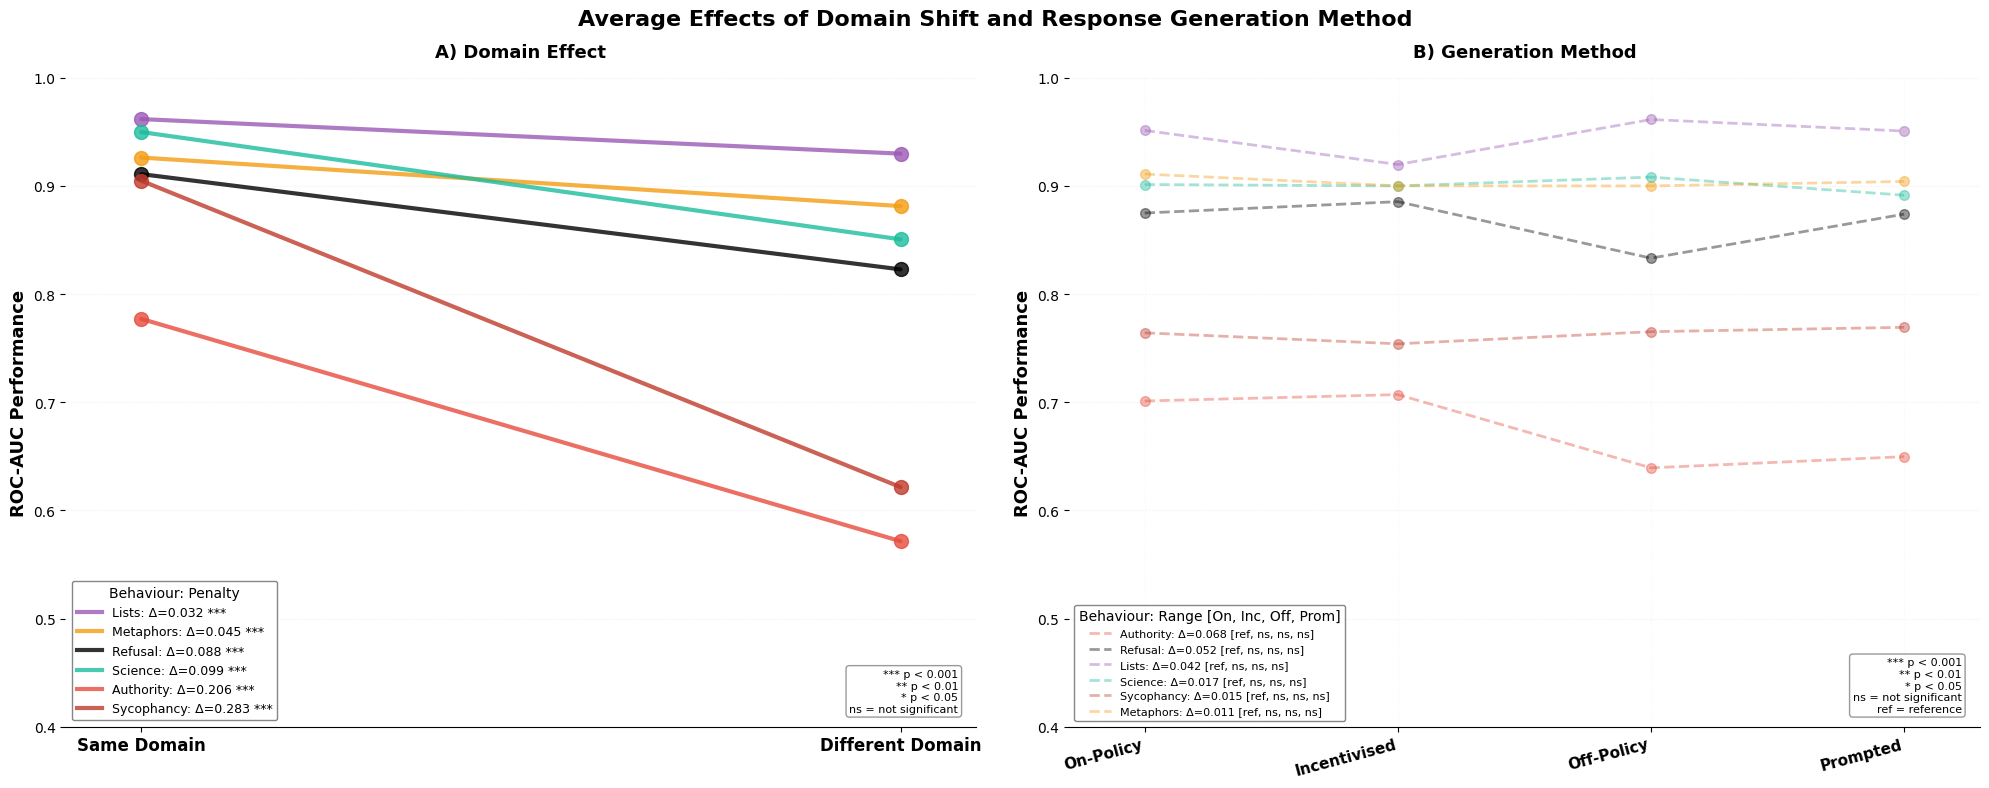

In [180]:

# This tests if domain effect varies by behaviour
model = smf.mixedlm("roc_auc ~ train_domain * C(behaviour) + generation_method",
                     data=results_test_on_policy,
                     groups=results_test_on_policy["behaviour"])
result = model.fit()
print(result.summary())


results_df['behaviour'] = pd.Categorical(
    results_df['behaviour'],
    categories=['lists', 'metaphors', 'science', 'refusal', 'sycophancy', 'authority'],
    ordered=False
)

# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_test_on_policy, 
    model_result=result,  # Your model from the mixed model fit
    save_path='domain_vs_generation.png'
)
plt.show()

### test on on-policy incentivised

In [181]:
import statsmodels.formula.api as smf
import pandas as pd

# Rename column for formula compatibility
results_test_incentivised['generation_method'] = results_test_incentivised['train_generation_method']

# Set 'on_policy' as the reference category for generation_method
results_test_incentivised['generation_method'] = pd.Categorical(
    results_test_incentivised['generation_method'],
    categories=['on_policy', 'incentivised', 'off_policy', 'prompted'],
    ordered=False
)

# Set 'same' as the reference category for train_domain
results_test_incentivised['train_domain'] = pd.Categorical(
    results_test_incentivised['train_domain'],
    categories=['same', 'different'],
    ordered=False
)

# Fit mixed linear model
model = smf.mixedlm("roc_auc ~ generation_method * train_domain",
                     data=results_test_incentivised,
                     groups=results_test_incentivised["behaviour"])
result = model.fit()
print(result.summary())

plt.show()

                                Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 roc_auc
No. Observations:                  54                      Method:                             REML   
No. Groups:                        8                       Scale:                              0.0079 
Min. group size:                   6                       Log-Likelihood:                     31.6305
Max. group size:                   8                       Converged:                          Yes    
Mean group size:                   6.8                                                                
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

/tmp/ipykernel_3060/1402243261.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_incentivised['generation_method'] = results_test_incentivised['train_generation_method']
/tmp/ipykernel_3060/1402243261.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_incentivised['generation_method'] = pd.Categorical(
/tmp/ipykernel_3060/1402243261.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [182]:
# This tests if domain effect varies by behaviour
model = smf.mixedlm("roc_auc ~ train_domain * C(behaviour) + generation_method",
                     data=results_test_incentivised,
                     groups=results_test_incentivised["behaviour"])
result = model.fit()
print(result.summary())


# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_df, 
    model_result=result,  # Your model from the mixed model fit
    save_path='domain_vs_generation.png'
)
plt.show()

                             Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               roc_auc
No. Observations:                54                    Method:                           REML   
No. Groups:                      8                     Scale:                            0.0018 
Min. group size:                 6                     Log-Likelihood:                   48.5632
Max. group size:                 8                     Converged:                        Yes    
Mean group size:                 6.8                                                            
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.788

/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


AttributeError: 'float' object has no attribute 'capitalize'